<a href="https://colab.research.google.com/github/luishleon/TalentoTech/blob/main/CopiaTaller_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

#Cargar el dataset

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

#Imprimir las primeras filas
df.head()
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
#Exploración Inicial
df.info()
df.isnull().sum()  #EXPLICAR EL RESULTADO DE ESTA LINEA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
import numpy as np

#Limpieza de Datos

# Rellenar Edad con la media
df["Age"] = df["Age"].fillna(df["Age"].mean())  #EXPLICAR EL RESULTADO DE ESTA LINEA

# Eliminar columna Cabin (muchos nulos), solo si existe
if "Cabin" in df.columns:
    df.drop(columns=["Cabin"], inplace=True)  #EXPLICAR EL RESULTADO DE ESTA LINEA

# Eliminar filas con Embarked nulo
df.dropna(subset=["Embarked"], inplace=True)  #EXPLICAR EL RESULTADO DE ESTA LINEA

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C


In [ ]:
# Análisis Exploratorio (EDA)
df["Survived"].value_counts(normalize=True) #EXPLICAR EL RESULTADO DE ESTA LINEA



,proportion
Survived,
0,0.617548
1,0.382452


In [ ]:
df.groupby("Sex")["Survived"].mean() #EXPLICAR EL RESULTADO DE ESTA LINEA

,Survived
Sex,
female,0.740385
male,0.188908


In [ ]:
df.groupby("Pclass")["Survived"].mean() #EXPLICAR EL RESULTADO DE ESTA LINEA

,Survived
Pclass,
1,0.626168
2,0.472826
3,0.242363


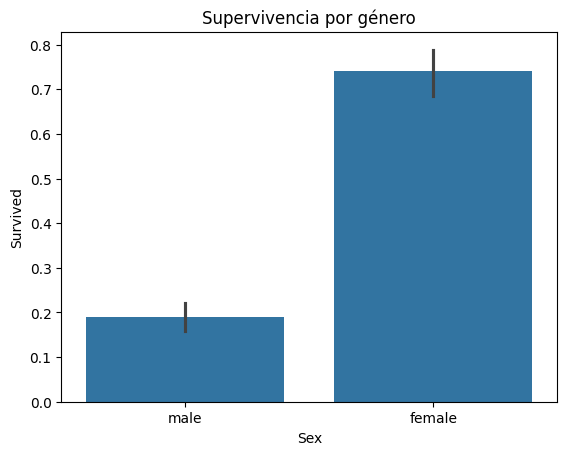

In [ ]:
#Visualización

import seaborn as sns
import matplotlib.pyplot as plt

# Supervivencia por género
sns.barplot(x="Sex", y="Survived", data=df)
plt.title("Supervivencia por género")
plt.show()


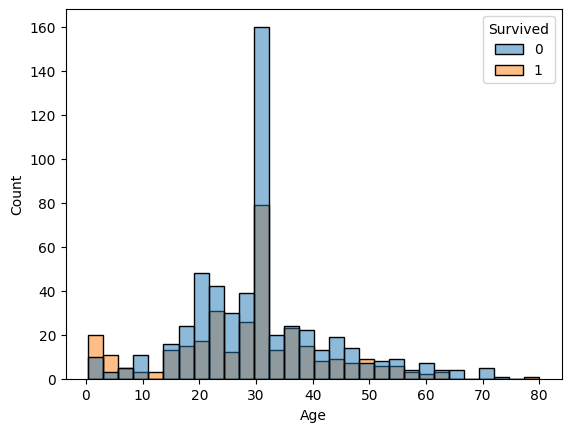

In [ ]:

# Edad vs supervivencia
sns.histplot(data=df, x="Age", hue="Survived", bins=30)
plt.show()


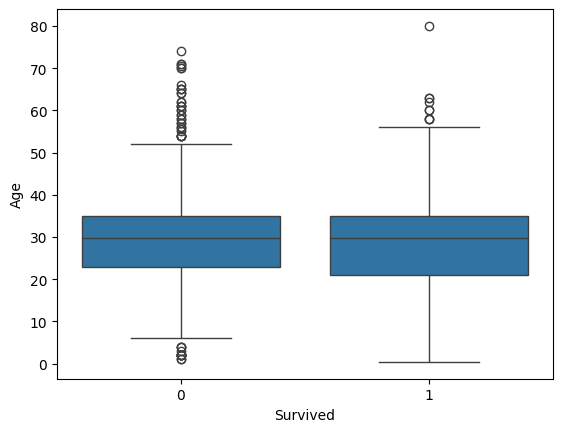

In [ ]:
# Boxplot
sns.boxplot(x="Survived", y="Age", data=df)
plt.show()

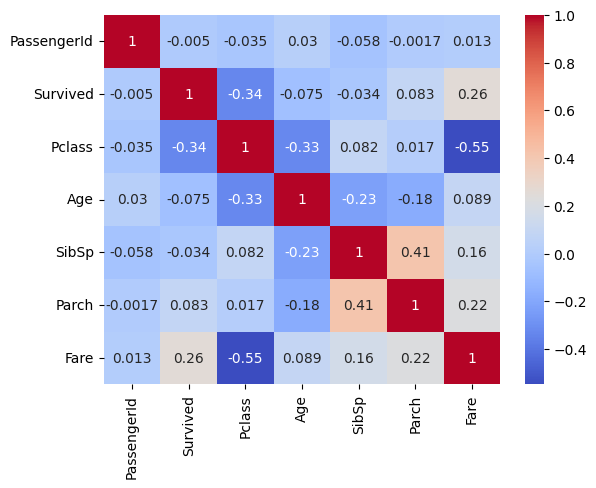

In [ ]:
#Correlaciones
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [ ]:
# Ingeniería de Variables
# Crear nueva variable: Familia a bordo
df["FamilySize"] = df["SibSp"] + df["Parch"]

# Clasificación simple
df["IsAlone"] = (df["FamilySize"] == 0).astype(int)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S,1,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C,1,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S,1,0
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,S,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,S,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S,3,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C,0,1


In [ ]:
#Calcular supervivencia por puerto de embarque:

df.groupby("Embarked")["Survived"].mean()

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


<Axes: xlabel='Survived', ylabel='Fare'>

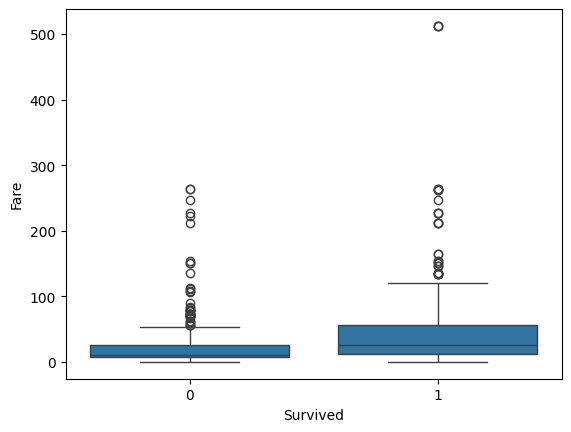

In [ ]:
#Graficar si el precio del ticket influye:

sns.boxplot(x="Survived", y="Fare", data=df)

In [ ]:
#Crear grupos de edad:

df["AgeGroup"] = pd.cut(df["Age"], bins=[0,12,18,35,60,100])

df.groupby("AgeGroup")["Survived"].mean()

/tmp/ipykernel_19942/604024239.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")["Survived"].mean()


,Survived
AgeGroup,
"(0, 12]",0.579710
"(12, 18]",0.428571
"(18, 35]",0.353271
"(35, 60]",0.396907
"(60, 100]",0.190476


In [ ]:
df["Age"] = df["Age"].astype(int)



### Análisis de Supervivencia por Tamaño de Familia

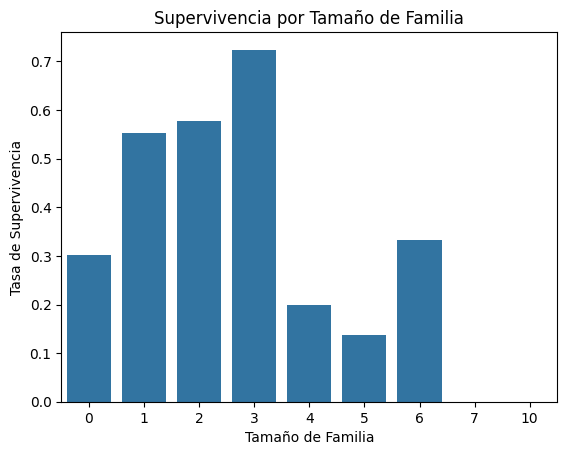

In [ ]:
family_survival = df.groupby('FamilySize')['Survived'].mean().reset_index()
sns.barplot(x='FamilySize', y='Survived', data=family_survival)
plt.title('Supervivencia por Tamaño de Familia')
plt.xlabel('Tamaño de Familia')
plt.ylabel('Tasa de Supervivencia')
plt.show()

### Análisis de Supervivencia de Solos vs. Acompañados

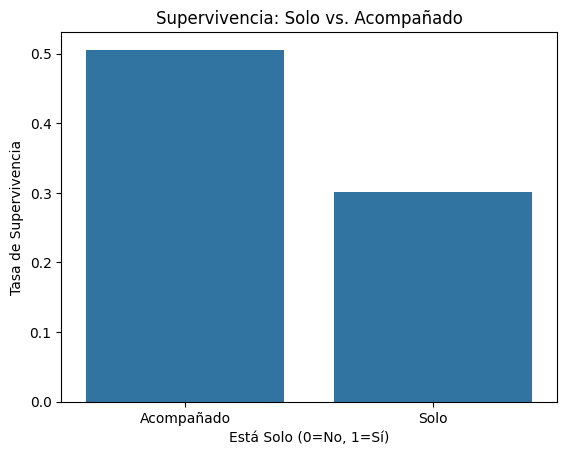

In [ ]:
alone_survival = df.groupby('IsAlone')['Survived'].mean().reset_index()
sns.barplot(x='IsAlone', y='Survived', data=alone_survival)
plt.title('Supervivencia: Solo vs. Acompañado')
plt.xlabel('Está Solo (0=No, 1=Sí)')
plt.ylabel('Tasa de Supervivencia')
plt.xticks([0, 1], ['Acompañado', 'Solo'])
plt.show()

### Análisis de Supervivencia por Puerto de Embarque

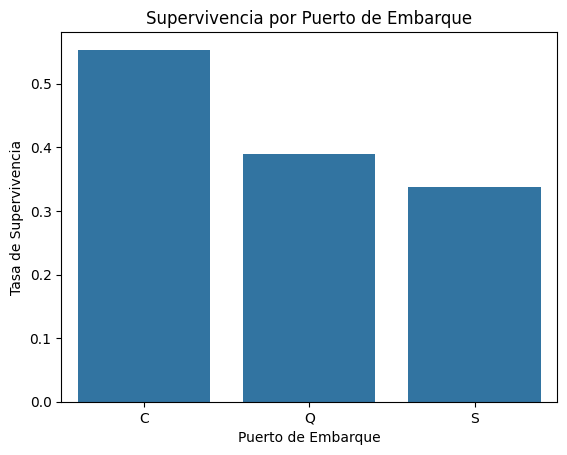

In [ ]:
embarked_survival = df.groupby('Embarked')['Survived'].mean().reset_index()
sns.barplot(x='Embarked', y='Survived', data=embarked_survival)
plt.title('Supervivencia por Puerto de Embarque')
plt.xlabel('Puerto de Embarque')
plt.ylabel('Tasa de Supervivencia')
plt.show()

In [ ]:
df["fare_per_person"] = df["Fare"] / (df["FamilySize"] + 1)
df [df ["Sex"] == "female"] ["Survived"].mean()
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df [df ["Sex"] == 0] ["Survived"].mean()
df["Age"].mean()

#df["Age"].mode()




np.float64(29.498312710911136)

In [ ]:
df["Age"].median()

29.0

In [ ]:
df.corr(numeric_only = True)["Survived"].sort_values(ascending=False)

,Survived
Survived,1.000000
Fare,0.255290
fare_per_person,0.217902
Parch,0.083151
FamilySize,0.018277
PassengerId,-0.005028
SibSp,-0.034040
Age,-0.072695
IsAlone,-0.206207
Pclass,-0.335549


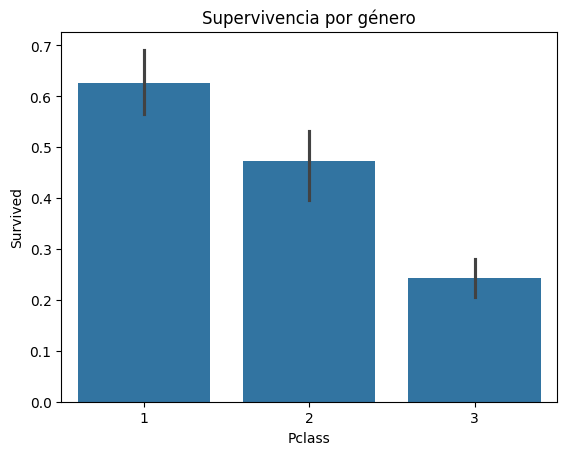

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(x="Pclass", y="Survived", data=df)
plt.title("Supervivencia por género")
plt.show()

#Tarea
- 3 visualizaciones propias
- 3 conclusiones nuevas
- 1 hipótesis basada en datos